# Gene expression prediction — evaluation

This notebook summarizes how well **parmigiano_joint** predicts **residualized** gene expression on each individual, using the **linear predictor** \( \hat{y} = G\,\bar{\beta} \) (posterior mean over variant effects), matching `calculate_r2` in `parmigiano_joint.py`.

## Metrics that matter here

1. **Per-gene \(R^2\) (train / test)** — Already saved as `train_r2_scores.csv` and `test_r2_scores.csv`. This is the usual variance-explained measure for continuous outcomes. Negative values mean the model is worse than predicting the gene-wise mean.
2. **Distribution of \(R^2\) across genes** — A few genes may dominate the average; histograms / ECDFs show how many genes are useful.
3. **Threshold counts** — Proportion of genes above \(R^2 > 0\), \(0.01\), \(0.1\) (or other cutoffs you care about for “usable" prediction).
4. **Train vs test gap** — Large drops on test indicate overfitting or limited generalization.
5. **Replication across runs** — Boxplots or error bars over runs (same experiment) show stability.
6. **Training ELBO / loss vs test \(R^2\)** — Rough sanity check: better optimization does not always mean better test \(R^2\), but wildly misaligned curves can flag bugs or instability.

**Not in the saved CSVs (optional extensions):** per-gene RMSE/MAE, Pearson/Spearman scatterplots of \(y\) vs \(\hat{y}\), or calibration require reloading \(G\), \(Y\), and \(\beta\) from the original data and `beta_samples/` — heavier I/O. Start with the metrics below; add those when you need finer-grained diagnostics for specific genes.

In [1]:
from __future__ import annotations

import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Same layout as in plot.ipynb — adjust if your runs live elsewhere
RESULTS_BASE = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_gene_results"
IGNORE_EXPERIMENT_PREFIXES = ("seed_genes_minmax_",)


def list_joint_experiments(base_dir: str = RESULTS_BASE):
    exps = []
    if not os.path.exists(base_dir):
        return exps
    for name in sorted(os.listdir(base_dir)):
        path = os.path.join(base_dir, name)
        if not os.path.isdir(path):
            continue
        if any(name.startswith(pref) for pref in IGNORE_EXPERIMENT_PREFIXES):
            continue
        exps.append((name, path))
    return exps


def discover_joint_runs(base_dir: str = RESULTS_BASE) -> pd.DataFrame:
    rows = []
    for exp_name, exp_path in list_joint_experiments(base_dir):
        for run_name in sorted(os.listdir(exp_path)):
            run_path = os.path.join(exp_path, run_name)
            if not os.path.isdir(run_path) or not run_name.startswith("run"):
                continue
            cfg_path = os.path.join(run_path, "config.yaml")
            row = {"experiment": exp_name, "run_id": run_name, "run_path": run_path}
            if os.path.exists(cfg_path):
                try:
                    with open(cfg_path, "r") as f:
                        cfg = yaml.safe_load(f)
                    if isinstance(cfg, dict):
                        row["lr"] = cfg.get("lr")
                        row["epochs"] = cfg.get("epochs")
                except Exception as e:
                    print(f"config read failed {run_path}: {e}")
            rows.append(row)
    return pd.DataFrame(rows) if rows else pd.DataFrame()


def load_r2_csv(run_path: str, split: str) -> pd.DataFrame | None:
    fname = "train_r2_scores.csv" if split == "train" else "test_r2_scores.csv"
    path = os.path.join(run_path, fname)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if "gene" not in df.columns or "r2" not in df.columns:
        return None
    return df[["gene", "r2"]].copy()


def load_final_loss(run_path: str) -> float | None:
    p = os.path.join(run_path, "losses.txt")
    if not os.path.exists(p):
        return None
    try:
        s = pd.read_csv(p, header=None).iloc[:, 0].dropna()
        return float(s.iloc[-1]) if len(s) else None
    except Exception:
        return None


runs_df = discover_joint_runs(RESULTS_BASE)
print(f"Discovered {len(runs_df)} runs across {runs_df['experiment'].nunique()} experiments.")
runs_df.head()

Discovered 679 runs across 7 experiments.


,experiment,run_id,run_path,lr,epochs
0,seed_genes_T_brr,run_1,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.05,500
1,seed_genes_T_brr,run_10,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.05,500
2,seed_genes_T_brr,run_100,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.05,500
3,seed_genes_T_brr,run_11,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.05,500
4,seed_genes_T_brr,run_12,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,0.05,500


In [2]:
def gather_per_gene_r2(runs_df: pd.DataFrame) -> pd.DataFrame:
    """Long table: experiment, run_id, run_path, gene, split, r2."""
    chunks = []
    for _, r in runs_df.iterrows():
        rp = r["run_path"]
        for split in ("train", "test"):
            d = load_r2_csv(rp, split)
            if d is None or d.empty:
                continue
            d = d.assign(
                experiment=r["experiment"],
                run_id=r["run_id"],
                run_path=rp,
                split=split,
            )
            chunks.append(d)
    if not chunks:
        return pd.DataFrame()
    return pd.concat(chunks, ignore_index=True)


def run_level_summary(r2_long: pd.DataFrame) -> pd.DataFrame:
    """One row per (experiment, run_id, split) with distributional summaries."""
    if r2_long.empty:
        return pd.DataFrame()
    g = r2_long.groupby(["experiment", "run_id", "run_path", "split"], as_index=False)
    out = g.agg(
        n_genes=("r2", "count"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
        frac_r2_pos=("r2", lambda s: float(np.mean(s > 0))),
        frac_r2_001=("r2", lambda s: float(np.mean(s > 0.01))),
        frac_r2_01=("r2", lambda s: float(np.mean(s > 0.1))),
    )
    return out


r2_long = gather_per_gene_r2(runs_df)
print(r2_long.groupby("split").size())
run_summary = run_level_summary(r2_long)
run_summary.head(10)

split
test     40740
train    40740
dtype: int64


,experiment,run_id,run_path,split,n_genes,mean_r2,median_r2,frac_r2_pos,frac_r2_001,frac_r2_01
0,seed_genes_T_brr,run_1,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,test,60,0.262330,0.223864,1.0,1.0,0.933333
1,seed_genes_T_brr,run_1,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,train,60,0.282853,0.263265,1.0,1.0,0.900000
2,seed_genes_T_brr,run_10,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,test,60,0.300856,0.258270,1.0,1.0,0.983333
3,seed_genes_T_brr,run_10,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,train,60,0.333088,0.316498,1.0,1.0,0.966667
4,seed_genes_T_brr,run_100,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,test,60,0.297341,0.259305,1.0,1.0,0.983333
5,seed_genes_T_brr,run_100,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,train,60,0.321268,0.300378,1.0,1.0,0.950000
6,seed_genes_T_brr,run_11,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,test,60,0.301300,0.261427,1.0,1.0,0.966667
7,seed_genes_T_brr,run_11,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,train,60,0.328708,0.307894,1.0,1.0,0.950000
8,seed_genes_T_brr,run_12,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,test,60,0.293255,0.247048,1.0,1.0,0.983333
9,seed_genes_T_brr,run_12,/gpfs/commons/home/vmazeeva/firvTWAS/parmigian...,train,60,0.315924,0.290735,1.0,1.0,0.950000


## Experiment-level comparison (mean ± std over runs)

Aggregate `mean_r2` and fraction-above-threshold metrics across runs within each experiment. Use this to rank configurations.

In [3]:
def experiment_summary(run_summary: pd.DataFrame) -> pd.DataFrame:
    if run_summary.empty:
        return pd.DataFrame()
    rows = []
    for (exp, split), sub in run_summary.groupby(["experiment", "split"]):
        rows.append(
            {
                "experiment": exp,
                "split": split,
                "n_runs": len(sub),
                "mean_r2_mean": sub["mean_r2"].mean(),
                "mean_r2_std": sub["mean_r2"].std(ddof=1) if len(sub) > 1 else 0.0,
                "median_r2_mean": sub["median_r2"].mean(),
                "frac_pos_mean": sub["frac_r2_pos"].mean(),
                "frac_001_mean": sub["frac_r2_001"].mean(),
                "frac_01_mean": sub["frac_r2_01"].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values(["split", "mean_r2_mean"], ascending=[True, False])


exp_sum = experiment_summary(run_summary)
print(exp_sum[exp_sum["split"] == "test"].to_string())

                 experiment split  n_runs  mean_r2_mean  mean_r2_std  median_r2_mean  frac_pos_mean  frac_001_mean  frac_01_mean
4   seed_genes_T_brr_clip10  test      73      0.294425     0.002953        0.253892       1.000000       0.997489      0.968721
6    seed_genes_T_brr_clip5  test     100      0.292946     0.002711        0.254788       1.000000       0.997000      0.970667
8        seed_genes_noT_brr  test     106      0.292838     0.002330        0.256622       1.000000       1.000000      0.969654
0          seed_genes_T_brr  test     100      0.287775     0.021523        0.249517       0.999667       0.999333      0.966000
2    seed_genes_T_brr_clip1  test     100      0.275117     0.007137        0.238060       0.999500       0.995000      0.959667
10          seed_genes_nowg  test     100      0.254913     0.037584        0.214538       0.995167       0.992000      0.922833
12   seed_genes_nowg_norhog  test     100      0.097648     0.049253        0.059795       0.8698

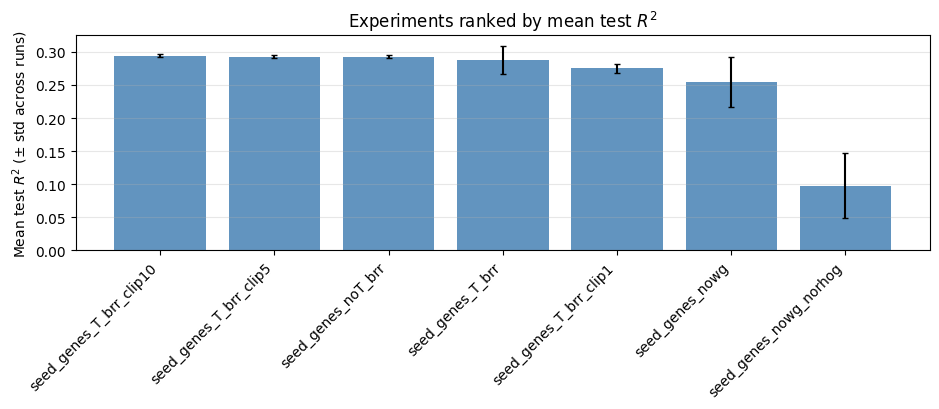

In [4]:
def plot_experiment_mean_test_r2(exp_sum: pd.DataFrame, top_n: int = 25):
    sub = exp_sum[exp_sum["split"] == "test"].copy()
    if sub.empty:
        print("No test rows in experiment summary.")
        return
    sub = sub.sort_values("mean_r2_mean", ascending=False).head(top_n)
    x = np.arange(len(sub))
    y = sub["mean_r2_mean"].values
    err = sub["mean_r2_std"].fillna(0).values
    plt.figure(figsize=(max(9, top_n * 0.38), 4.2))
    plt.bar(x, y, yerr=err, capsize=2, color="steelblue", alpha=0.85)
    plt.xticks(x, sub["experiment"], rotation=45, ha="right")
    plt.ylabel("Mean test $R^2$ (± std across runs)")
    plt.title("Experiments ranked by mean test $R^2$")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_experiment_mean_test_r2(exp_sum)

## Plots

- **ECDF** of per-gene test \(R^2\) (one curve per experiment, mean over runs).
- **Train vs test** mean \(R^2\) per run.
- **Final ELBO vs mean test \(R^2\)** per run (if `losses.txt` exists).

In `run_summary`, `frac_r2_01` is the fraction of genes with test/train \(R^2 > 0.1\); `frac_r2_001` uses the \(0.01\) cutoff.

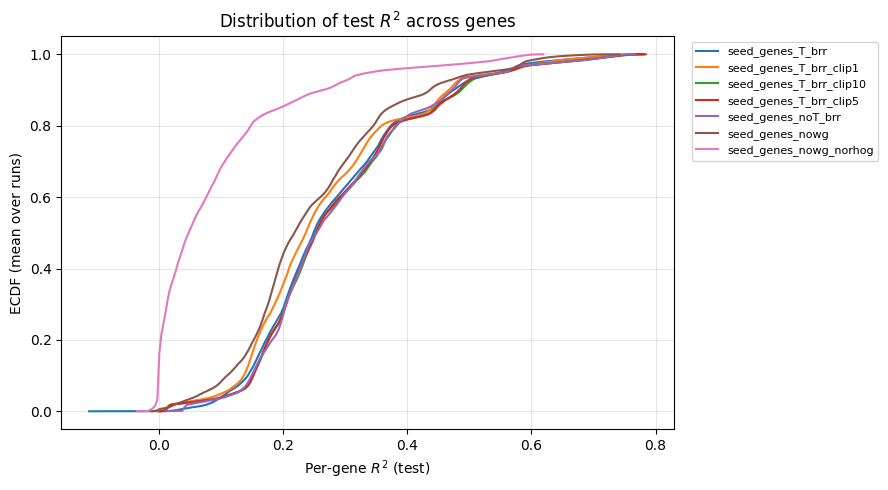

In [5]:
def plot_ecdf_test_r2(r2_long: pd.DataFrame, max_experiments: int = 12):
    test = r2_long[r2_long["split"] == "test"].copy()
    if test.empty:
        print("No test R2 loaded.")
        return
    exps = sorted(test["experiment"].unique())[:max_experiments]
    plt.figure(figsize=(9, 5))
    for exp in exps:
        sub = test[test["experiment"] == exp]
        # Mean ECDF across runs: average the step functions at a grid
        curves = []
        for _, rsub in sub.groupby("run_id"):
            x = np.sort(rsub["r2"].values.astype(float))
            if len(x) == 0:
                continue
            y = np.arange(1, len(x) + 1) / len(x)
            curves.append((x, y))
        if not curves:
            continue
        x0 = min(c[0].min() for c in curves)
        x1 = max(c[0].max() for c in curves)
        if x1 - x0 < 1e-12:
            x1 = x0 + 1e-6
        xs = np.linspace(x0, x1, 200)
        interp = []
        for x, y in curves:
            interp.append(np.interp(xs, x, y, left=0.0, right=1.0))
        mean_curve = np.mean(interp, axis=0)
        plt.plot(xs, mean_curve, label=exp)
    plt.xlabel(r"Per-gene $R^2$ (test)")
    plt.ylabel("ECDF (mean over runs)")
    plt.title("Distribution of test $R^2$ across genes")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_ecdf_test_r2(r2_long)

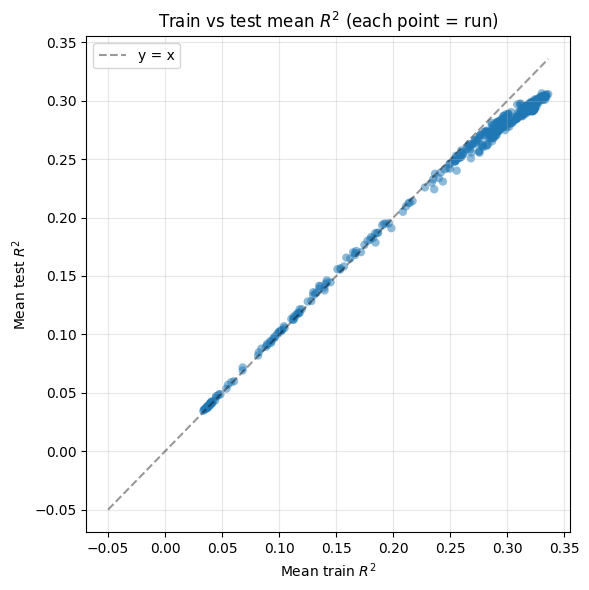

In [6]:
def plot_train_vs_test_mean_r2(run_summary: pd.DataFrame):
    if run_summary.empty:
        return
    tr = run_summary[run_summary["split"] == "train"].set_index(["experiment", "run_id"])["mean_r2"]
    te = run_summary[run_summary["split"] == "test"].set_index(["experiment", "run_id"])["mean_r2"]
    joined = pd.DataFrame({"train": tr, "test": te}).dropna()
    if joined.empty:
        print("Need both train and test per run for this plot.")
        return
    plt.figure(figsize=(6, 6))
    plt.scatter(joined["train"], joined["test"], alpha=0.5, edgecolors="none")
    lo = min(joined.min().min(), -0.05)
    hi = max(joined.max().max(), 0.05)
    plt.plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="y = x")
    plt.xlabel("Mean train $R^2$")
    plt.ylabel("Mean test $R^2$")
    plt.title("Train vs test mean $R^2$ (each point = run)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_train_vs_test_mean_r2(run_summary)

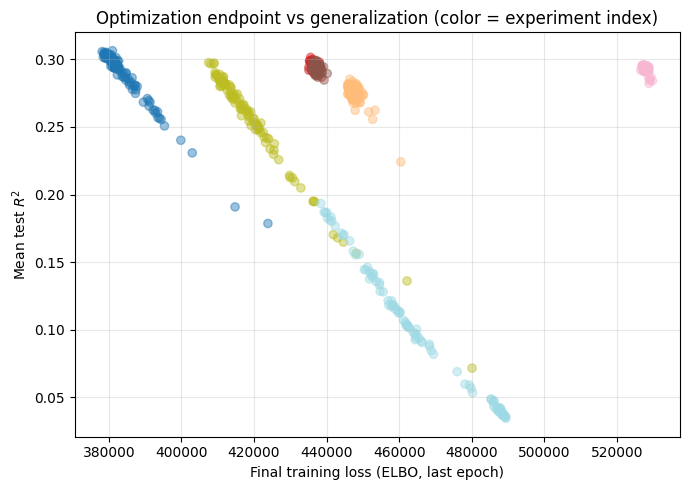

In [7]:
def plot_loss_vs_test_mean_r2(runs_df: pd.DataFrame, run_summary: pd.DataFrame):
    te = run_summary[run_summary["split"] == "test"].copy()
    if te.empty:
        return
    losses = []
    for _, r in runs_df.iterrows():
        losses.append({"run_path": r["run_path"], "final_loss": load_final_loss(r["run_path"])})
    L = pd.DataFrame(losses)
    m = te.merge(L, on="run_path", how="left")
    m = m.dropna(subset=["final_loss", "mean_r2"])
    if m.empty:
        print("No overlapping final loss + test mean R2.")
        return
    plt.figure(figsize=(7, 5))
    plt.scatter(m["final_loss"], m["mean_r2"], alpha=0.45, c=pd.Categorical(m["experiment"]).codes, cmap="tab20")
    plt.xlabel("Final training loss (ELBO, last epoch)")
    plt.ylabel("Mean test $R^2$")
    plt.title("Optimization endpoint vs generalization (color = experiment index)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_loss_vs_test_mean_r2(runs_df, run_summary)

## Per-gene train vs test \(R^2\) for one run

Scatter identifies genes that generalize vs those that overfit. Pick a `run_path` below.

RUN_TO_INSPECT: /gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_gene_results/seed_genes_T_brr/run_1


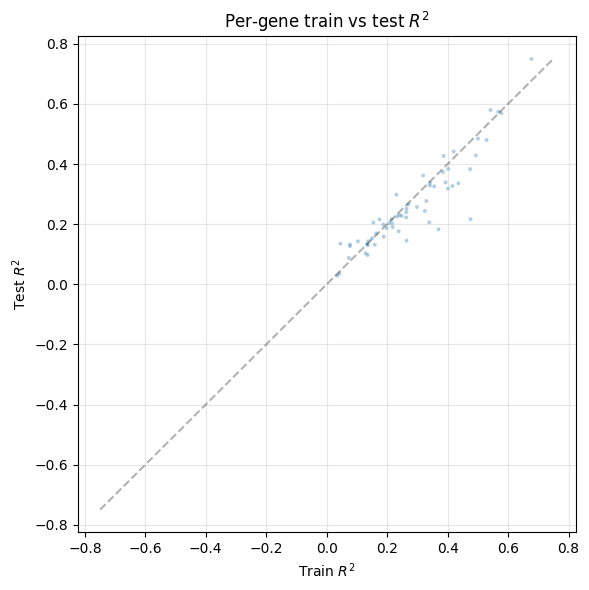

In [8]:
# Example: first run with both train and test files
def first_run_with_both(runs_df: pd.DataFrame) -> str | None:
    for _, r in runs_df.iterrows():
        rp = r["run_path"]
        if load_r2_csv(rp, "train") is not None and load_r2_csv(rp, "test") is not None:
            return rp
    return None


RUN_TO_INSPECT = first_run_with_both(runs_df)
print("RUN_TO_INSPECT:", RUN_TO_INSPECT)

if RUN_TO_INSPECT:
    a = load_r2_csv(RUN_TO_INSPECT, "train").rename(columns={"r2": "r2_train"})
    b = load_r2_csv(RUN_TO_INSPECT, "test").rename(columns={"r2": "r2_test"})
    both = a.merge(b, on="gene", how="inner")
    plt.figure(figsize=(6, 6))
    plt.scatter(both["r2_train"], both["r2_test"], s=8, alpha=0.35, edgecolors="none")
    lim = max(0.05, float(np.nanmax(np.abs(both[["r2_train", "r2_test"]].values))))
    plt.plot([-lim, lim], [-lim, lim], "k--", alpha=0.3)
    plt.xlabel("Train $R^2$")
    plt.ylabel("Test $R^2$")
    plt.title("Per-gene train vs test $R^2$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()